In [8]:
import os

os.environ['KAGGLE_API_TOKEN'] = "KGAT_b13bd16090755d5033a2e60ce31309ce"

In [12]:
import os

os.environ['KAGGLE_USERNAME'] = "abhisoumyakapoor"
os.environ['KAGGLE_KEY'] = "KGAT_b13bd16090755d5033a2e60ce31309ce"

!kaggle datasets download -d tawsifurrahman/covid19-radiography-database
!unzip -q covid19-radiography-database.zip

!rm -rf "COVID-19_Radiography_Dataset/Lung_Opacity"
!rm -rf "COVID-19_Radiography_Dataset/COVID/masks"
!rm -rf "COVID-19_Radiography_Dataset/Normal/masks"
!rm -rf "COVID-19_Radiography_Dataset/Viral Pneumonia/masks"

print("Data downloaded, unzipped, and cleaned successfully!")

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
covid19-radiography-database.zip: Skipping, found more recently modified local copy (use --force to force download)
replace COVID-19_Radiography_Dataset/COVID.metadata.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: Data downloaded, unzipped, and cleaned successfully!


In [16]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

data_dir = 'COVID-19_Radiography_Dataset'
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Total images found: {len(full_dataset)}")
print(f"Classes: {full_dataset.classes}")
print("Data is locked and loaded. Ready for the model!")

Total images found: 15153
Classes: ['COVID', 'Normal', 'Viral Pneumonia']
Data is locked and loaded. Ready for the model!


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}")

print("Training complete!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 142MB/s]


Epoch 1/5 - Loss: 0.1085
Epoch 2/5 - Loss: 0.0296
Epoch 3/5 - Loss: 0.0174
Epoch 4/5 - Loss: 0.0085
Epoch 5/5 - Loss: 0.0125
Training complete!


In [21]:
from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

target_names = full_dataset.classes
report = classification_report(all_labels, all_preds, target_names=target_names)
print(report)

torch.save(model.state_dict(), 'covid_resnet18.pth')
print("Model saved as covid_resnet18.pth")

                 precision    recall  f1-score   support

          COVID       0.99      0.98      0.99       696
         Normal       0.99      0.99      0.99      2046
Viral Pneumonia       0.97      1.00      0.98       289

       accuracy                           0.99      3031
      macro avg       0.99      0.99      0.99      3031
   weighted avg       0.99      0.99      0.99      3031

Model saved as covid_resnet18.pth


In [22]:
!pip install grad-cam

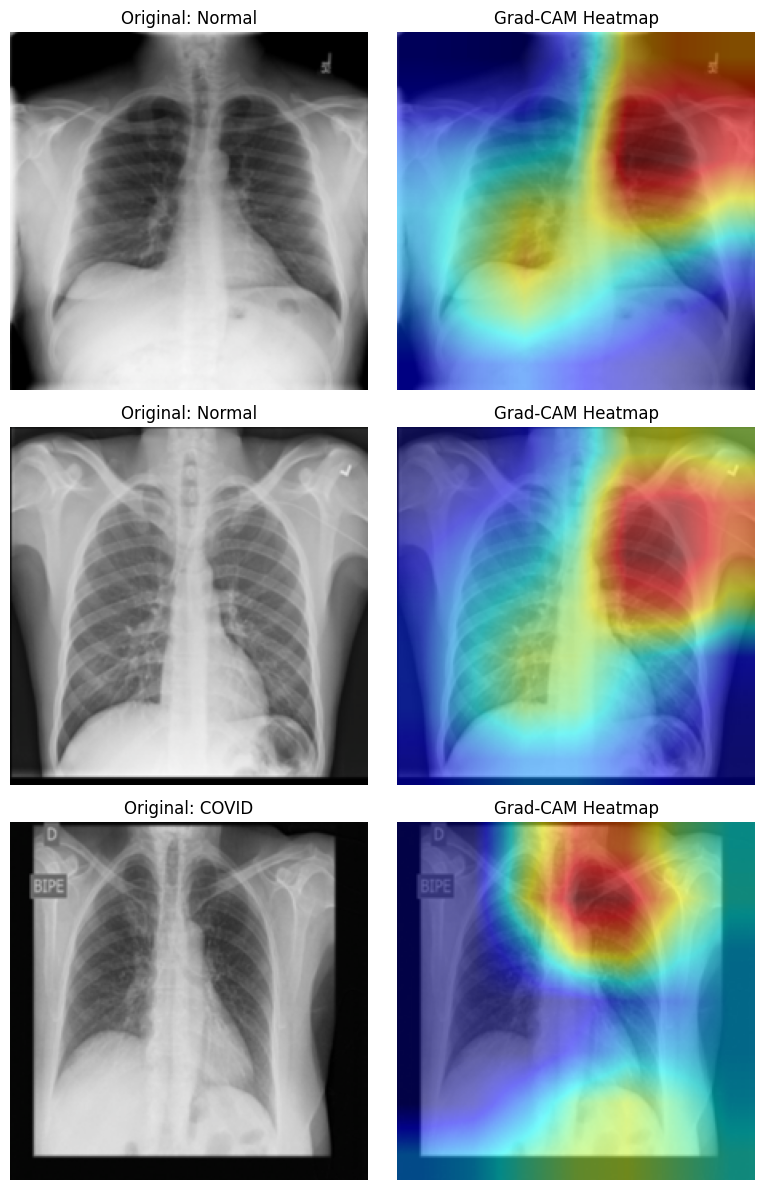

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

dataiter = iter(test_loader)
images, labels = next(dataiter)
input_tensor = images.to(device)

grayscale_cams = cam(input_tensor=input_tensor)

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

fig, axes = plt.subplots(3, 2, figsize=(8, 12))

for i in range(3):
    img = images[i]
    unnorm_img = inv_normalize(img).permute(1, 2, 0).numpy()
    unnorm_img = np.clip(unnorm_img, 0, 1)

    grayscale_cam = grayscale_cams[i, :]
    visualization = show_cam_on_image(unnorm_img, grayscale_cam, use_rgb=True)

    axes[i, 0].imshow(unnorm_img)
    axes[i, 0].set_title(f"Original: {full_dataset.classes[labels[i].item()]}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(visualization)
    axes[i, 1].set_title("Grad-CAM Heatmap")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [25]:
import torch.nn.functional as F
from scipy.stats import entropy

img_idx = 0
single_img = images[img_idx].unsqueeze(0).to(device)
single_label = labels[img_idx].item()
heatmap = grayscale_cams[img_idx]

heatmap_1d = heatmap.flatten()
heatmap_probs = heatmap_1d / heatmap_1d.sum()
map_entropy = entropy(heatmap_probs, base=2)

print(f"--- EXPLAINABILITY METRICS ---")
print(f"Entropy of the Saliency Map: {map_entropy:.4f}")

model.eval()
with torch.no_grad():
    base_out = model(single_img)
    base_prob = F.softmax(base_out, dim=1)[0, single_label].item()

flat_indices = np.argsort(heatmap_1d)[::-1]
pixels_per_step = int(len(flat_indices) * 0.1)

drop_curve = [base_prob]
print(f"Base Probability (0% deleted): {base_prob:.4f}")

for step in range(1, 11):
    mask = torch.ones_like(single_img)
    pixels_to_delete = flat_indices[:step * pixels_per_step]

    for idx in pixels_to_delete:
        row, col = divmod(idx, 224)
        mask[0, :, row, col] = 0

    masked_img = single_img * mask

    with torch.no_grad():
        out = model(masked_img)
        prob = F.softmax(out, dim=1)[0, single_label].item()

    drop_curve.append(prob)
    print(f"Probability after {step*10}% deletion: {prob:.4f}")

aopc = np.trapz(drop_curve, dx=0.1)
print(f"AOPC (Area Over Perturbation Curve): {aopc:.4f}")

--- EXPLAINABILITY METRICS ---
Entropy of the Saliency Map: 15.2535
Base Probability (0% deleted): 0.9999
Probability after 10% deletion: 0.9871
Probability after 20% deletion: 0.7742
Probability after 30% deletion: 0.1930
Probability after 40% deletion: 0.0261
Probability after 50% deletion: 0.0084
Probability after 60% deletion: 0.0025
Probability after 70% deletion: 0.0017
Probability after 80% deletion: 0.0023
Probability after 90% deletion: 0.0038
Probability after 100% deletion: 0.0113
AOPC (Area Over Perturbation Curve): 0.2505


/tmp/ipykernel_1276/4270263500.py:44: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aopc = np.trapz(drop_curve, dx=0.1)
